# Note to self - Libraries allowed
Only the following libraries will be allowed to be used in the competition:

NumPy Pandas Matplotlib Scikit-learn XGBoost Seaborn Imblearn SciPy regex Lightgbm Plotly statsmodel Wordcloud Catboost

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_log_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, RobustScaler
from catboost import CatBoostRegressor
import lightgbm as lgb
from xgboost import XGBRegressor

import warnings

warnings.filterwarnings('ignore')
train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")
sample_ = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv")

# Milestone 1

In [2]:
# 1
# print(train.shape, test.shape)
# 2
# print(set(train)-set(test))
# 3
# print(train.select_dtypes(include='number').shape)
# 4
# train.isna().sum()[train.isna().sum() >= 124800]
# 5
# (train['OperationalHoursMeter'].isna().sum()/138701)*100
# 6
# train["TargetValue"].median()
# 7
# train['ManufactureYear'].value_counts().head(1)
# 8
# train['TransactionDate'].min()
# 9
# train['Spec_BaseClass'].dropna().nunique()
# 10
# train['RegionCode'].value_counts().head(1)
# 11
# train.loc[train["RegionCode"] == 'Florida', "TargetValue"].mean()
# 12
# train['UtilizationTier'].value_counts()
# 13
# train['TargetValue'].corr(train['OperationalHoursMeter'])
# 14
# train['FunctionalClassification'].value_counts()

# End of Milestone 1

# Milestone 2

In [3]:
# train['TransactionDate'] = pd.to_datetime(train['TransactionDate'], dayfirst=True)
# train['TransactionYear'] = train['TransactionDate'].dt.year
# train['TransactionQuarter'] = train['TransactionDate'].dt.quarter
# train['AssetAge'] = train['TransactionYear'] - train['ManufactureYear']
# train['DescriptorLength'] = train['Spec_FullDescriptor'].fillna('').str.len()
# train['HasOperationalHours'] = train['OperationalHoursMeter'].notna().astype(int)
# train['HasVariantModifier'] = train['Spec_VariantModifier'].notna().astype(int)

# train = pd.get_dummies(
#     train,
#     columns=['RegionCode', 'CabinType', 'UtilizationTier'],
#     drop_first=True
# )

# numeric_train = train.select_dtypes(include='number')
# corr_matrix = numeric_train.corr(method='pearson')

# cols = ['ManufactureYear', 'OperationalHoursMeter', 'AssetAge']
# imputer = SimpleImputer(strategy='mean')
# train[cols] = imputer.fit_transform(train[cols])
# scaler = StandardScaler()
# train[cols] = scaler.fit_transform(train[cols])

# X = train.drop('TargetValue', axis=1)
# y = train['TargetValue']

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# features = ['ManufactureYear', 'AssetAge']
# X_train_lr = X_train[features]
# X_val_lr = X_val[features]
# model = LinearRegression()
# model.fit(X_train_lr, y_train)

In [4]:
# 1
# train['AssetAge'].value_counts()
# 2
# train.groupby('TransactionQuarter')['TargetValue'].mean().idxmax()
# 3
# train['DescriptorLength'].value_counts()
# 4
# train['HasOperationalHours'].value_counts()
# 5
# (train['HasVariantModifier'].mean()) * 100 NOTE: mean() works bcoz the numbers are binary
# 6
# train['ManufactureYear'].mean()
# 7
# sum(col.startswith(('RegionCode_', 'CabinType_', 'UtilizationTier_'))
#    for col in train.columns)
# 8
# corr_matrix
# 9
# X_train.shape
# 10
# X_val.shape
# 11
# y_pred = model.predict(X_val_lr)
# r2 = r2_score(y_val, y_pred)
# print("R²  :", r2)

# End of Milestone 2

# Milestone 3

In [5]:
# Datetime Extraction
'''
train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])
train['SaleYear'] = train['TransactionDate'].dt.year
most_frequent_year = train['SaleYear'].mode()[0]
frequency = train['SaleYear'].value_counts().iloc[0]

print(f"{most_frequent_year}")
print(f"{frequency}")
'''
# Imputing Missing Numeric Data 
'''
hours = train['OperationalHoursMeter']
mean_val = hours.mean()
median_val = hours.median()
skewness = hours.skew()

print(f"Mean: {mean_val}")
print(f"Median: {median_val}")
print(f"Skewness: {skewness}")
'''
# Feature Interaction (Intensity)
'''
train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])
train['SaleYear'] = train['TransactionDate'].dt.year
train['AssetAge'] = train['SaleYear'] - train['ManufactureYear']
train['HoursPerYear'] = train['OperationalHoursMeter'] / train['AssetAge']
valid_hours = train['HoursPerYear'].replace([np.inf, -np.inf], np.nan).dropna()
median_intensity = valid_hours.median()
print(f"{median_intensity}")
print(f"{len(valid_hours)}")
'''
# Calculating Asset Age
'''
train['ManufactureYear'] = train['ManufactureYear'].replace([1000, 1001], np.nan)
train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])
train['SaleYear'] = train['TransactionDate'].dt.year
train['AssetAge'] = train['SaleYear'] - train['ManufactureYear']
median_asset_age = train['AssetAge'].median()
print(f"Median AssetAge: {median_asset_age}")
'''
# Imputing Missing Categorical Data
'''
missing_count = train['CabinType'].isnull().sum()
existing_missing_string_count = (train['CabinType'] == "Missing").sum()
print(f"{missing_count}")
print(f"{existing_missing_string_count}")
'''
# Dropping Sparse Features
'''
missing_fractions = train.isnull().mean()
cols_to_drop = missing_fractions[missing_fractions > 0.8]
num_cols_to_drop = len(cols_to_drop)
print(f"{num_cols_to_drop}")
print(list(cols_to_drop.index))
'''
# Train-Test Split Verification
'''
X = train.drop(columns=['TargetValue'])
y = train['TargetValue']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train rows: {X_train.shape[0]}")
'''
# Ordinal Encoding Application
'''
unique_vals = train['UtilizationTier'].unique()
print(f"{unique_vals}")
print(f"Number of unique values (including NaN): {len(unique_vals)}")
'''
# Log Transforming the Target
'''
train['TargetValue_log1p'] = np.log1p(train['TargetValue'])
std_dev = train['TargetValue_log1p'].std()
print(std_dev)
'''

"\ntrain['TargetValue_log1p'] = np.log1p(train['TargetValue'])\nstd_dev = train['TargetValue_log1p'].std()\nprint(std_dev)\n"

# End of Milestone 3

In [6]:
train.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [7]:
print(train.shape, test.shape)

(138701, 50) (15000, 49)


# Detailed analysis of each column

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [9]:
train.describe()

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06


# Dropping unnecessary columns having no feature
* col4, col5, col18, col19 ... haad too many NULL values to impute

In [10]:
train.drop(columns=['col4', 'col5', 'col18', 'col19',], inplace=True)
test.drop(columns=['col4', 'col5', 'col18', 'col19',], inplace=True)

# Visualisation

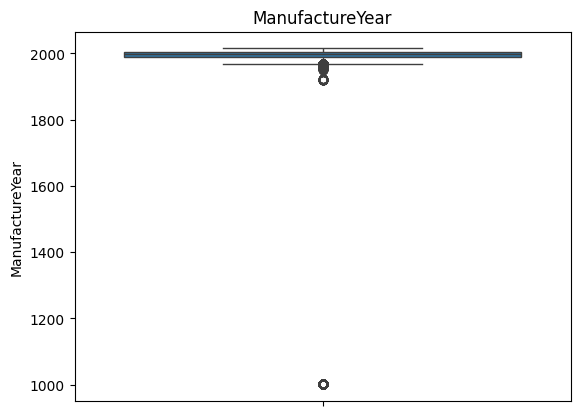

In [11]:
sns.boxplot(y=train["ManufactureYear"])

plt.title("ManufactureYear")
plt.show()

### *ManufactureYear* has an extreme outlier = 1001

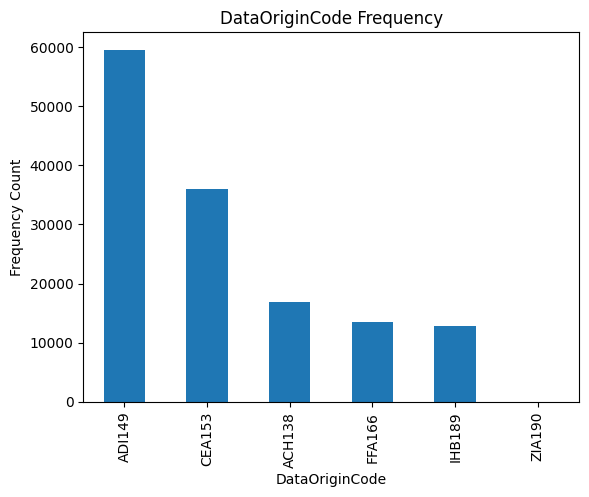

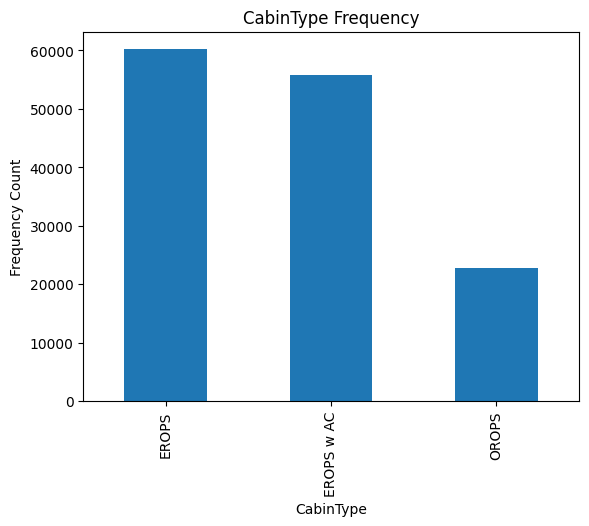

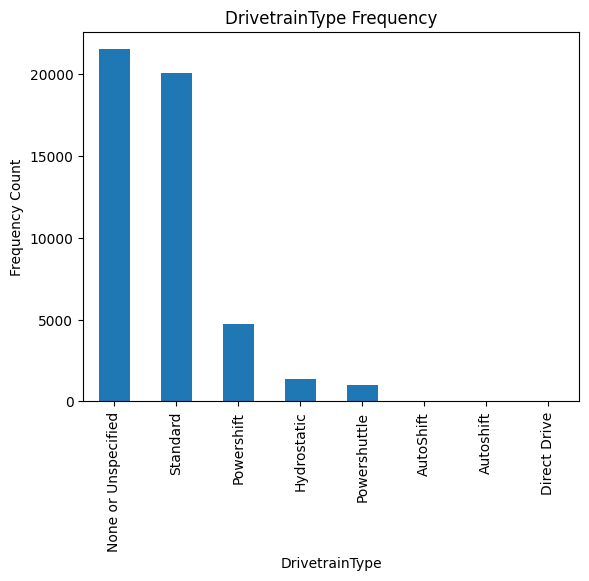

In [12]:
for col in ["DataOriginCode", "CabinType", "DrivetrainType"]:
    train[col].value_counts().plot(kind="bar")

    plt.title(f"{col} Frequency")
    plt.xlabel(col)
    plt.ylabel("Frequency Count")
    plt.show()

### *ADI149* most frequent in *DataOriginCode*
### *EROPS* most frequent in *CabinType*
### *Standard* most frequent in *DriveType*

# Data cleaning/preprocessing (manual mapping)

In [13]:
# ManufactureYear

years = train.loc[train["ManufactureYear"] != 1001, "ManufactureYear"]
median_year = years.median()

train["ManufactureYear"] = train["ManufactureYear"].replace(1001, median_year)
test["ManufactureYear"] = test["ManufactureYear"].replace(1001, median_year)

# Visualisation

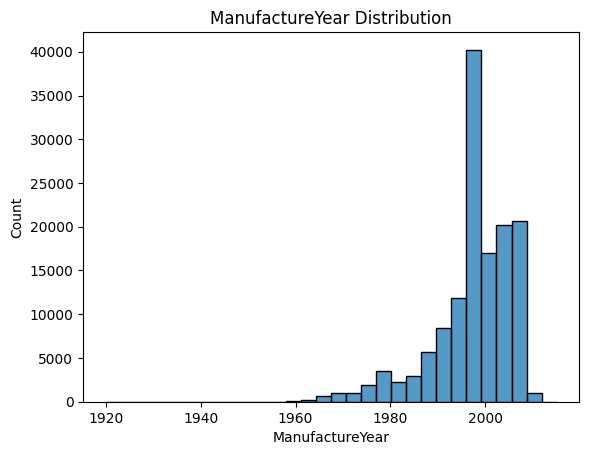

In [14]:
sns.histplot(train["ManufactureYear"], bins=30)
plt.title("ManufactureYear Distribution")
plt.show()

### *ManufactureYear* extreme outlier = 1001 has been removed

In [15]:
# UtilizationTier

util_mapping = {
    "High": 3,
    "Medium": 2,
    "Low": 1,
}

train["UtilizationTier"] = train["UtilizationTier"].fillna(0).map(util_mapping)
test["UtilizationTier"] = test["UtilizationTier"].fillna(0).map(util_mapping)

In [16]:
# TransactionYear

train["TransactionYear"] = pd.to_datetime(train["TransactionDate"]).dt.year
test["TransactionYear"] = pd.to_datetime(test["TransactionDate"]).dt.year

# MachineAge

train["MachineAge"] = train["TransactionYear"] - train["ManufactureYear"]
test["MachineAge"] = test["TransactionYear"] - test["ManufactureYear"]

In [17]:
# Spec_SubClass, Spec_ReleaseSeries

train["Spec_SubClass"] = train["Spec_SubClass"].replace("#NAME?", np.nan)
test["Spec_SubClass"] = test["Spec_SubClass"].replace("#NAME?", np.nan)

train["Spec_ReleaseSeries"] = train["Spec_ReleaseSeries"].replace("#NAME?", np.nan)
test["Spec_ReleaseSeries"] = test["Spec_ReleaseSeries"].replace("#NAME?", np.nan)

In [18]:
# AssetScaleFactor

scale_mapping = {
    "Mini": 1,
    "Compact": 2,
    "Small": 3,
    "Medium": 4,
    "Large / Medium": 5,
    "Large": 6,
}

train["AssetScaleFactor"] = train["AssetScaleFactor"].map(scale_mapping)
test["AssetScaleFactor"] = test["AssetScaleFactor"].map(scale_mapping)

In [19]:
# FunctionalClassification

'''
Example: | Wheel Loader - 150.0 to 175.0 Horsepower |
'''

# MachineCapacity
train["MachineCapacity"] = train["FunctionalClassification"].str.split(" - ").str[1]
test["MachineCapacity"] = test["FunctionalClassification"].str.split(" - ").str[1]

train.drop(columns=["FunctionalClassification"], inplace=True)
test.drop(columns=["FunctionalClassification"], inplace=True)

In [20]:
# col7

col7_mapping = {
    "<12'": 10,
    "12'": 12,
    "13'": 13,
    "14'": 14,
    "16'": 16,
}

for df in [train, test]:
    if "col7" in df.columns:
        df["col7"] = df["col7"].map(col7_mapping)
        df["col7"] = df["col7"].fillna(0).astype(int)

In [21]:
# col10

col10_mapping = {
    "Standard": 2,
    "Auxiliary": 3,
    "2 Valve": 2,
    "Base + 1 Function": 2,
    "3 Valve": 3,
    "Base + 2 Function": 3,
    "4 Valve": 4,
    "Base + 3 Function": 4,
    "Base + 4 Function": 5,
    "Base + 5 Function": 6,
    "Base + 6 Function": 7,
}

for df in [train, test]:
    if "col10" in df.columns:
        df["col10"] = df["col10"].map(col10_mapping)
        df["col10"] = df["col10"].fillna(0).astype(int)

In [22]:
# col15

'''
Example: | 15.5" | 29.5 |
'''

for df in [train, test]:
    df["col15_inch"] = df["col15"].astype(str)

    df["col15_inch"] = df["col15_inch"].str.replace('"', "")
    df["col15_inch"] = df["col15_inch"].replace(
        ["None or Unspecified"], np.nan
    )

    df["col15_inch"] = pd.to_numeric(df["col15_inch"], errors="coerce")

train.drop(columns=["col15"], inplace=True)
test.drop(columns=["col15"], inplace=True)

In [23]:
# col21

'''
Example: | 16 inch |
'''

for df in [train, test]:
    if "col21" in df.columns:
        df["col21"] = df["col21"].astype(str).str.split(" ").str[0]

        # None or Unspecified
        df["col21"] = df["col21"].replace(["None", "nan", "None or Unspecified"], np.nan)
        df["col21"] = pd.to_numeric(df["col21"], errors="coerce")

In [24]:
# col22

'''
Example: | 10' 2" |
'''

def scale(text_):
    if (
        pd.isna(text_)
        or text_ == "None or Unspecified"
        or str(text_).strip() in ["nan", "None", ""]
    ):
        return np.nan

    try:
        parts = str(text_).replace('"', "").split("'")
        feet = float(parts[0].strip())

        inches = float(parts[1].strip()) if len(parts) > 1 and parts[1].strip() else 0.0

        return (feet * 12) + inches
    except Exception:
        return np.nan


for df in [train, test]:
    if "col22" in df.columns:
        df["col22"] = df["col22"].apply(scale)

# Random string -> np.nan
# None or Unspecified -> np.nan
# return -> feet*12 + inches

In [25]:
# col25

col25_mapping = {
    "Single": 1,
    "Double": 2,
    "Triple": 3
}

for df in [train, test]:
    if "col25" in df.columns:
        df["col25"] = df["col25"].map(col25_mapping)
        df["col25"] = df["col25"].fillna(-1).astype(int)

In [26]:
train = train.replace("None or Unspecified", np.nan)
test = test.replace("None or Unspecified", np.nan)

# Visualisation

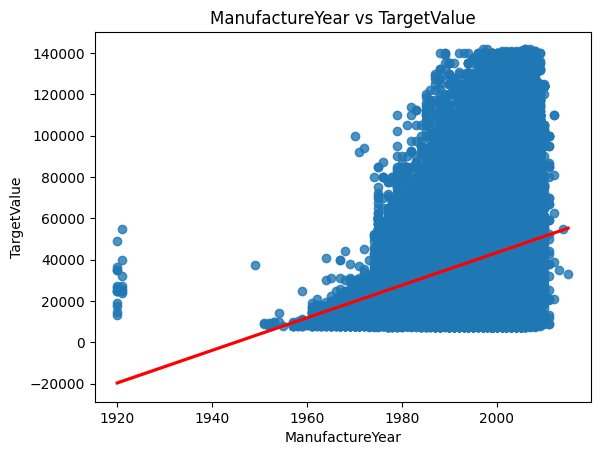

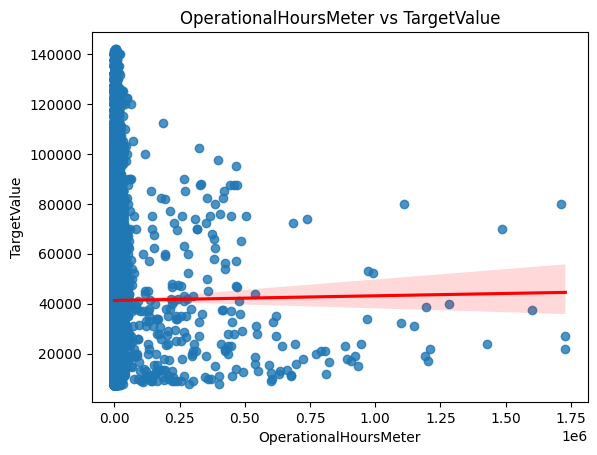

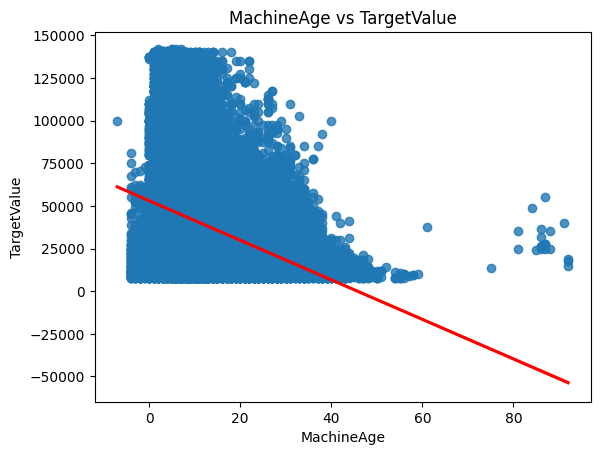

In [27]:
for col in ["ManufactureYear", "OperationalHoursMeter", "MachineAge"]:
    sns.regplot(data=train, x=col, y="TargetValue", line_kws={"color": "red"})

    plt.title(f"{col} vs TargetValue")
    plt.show()

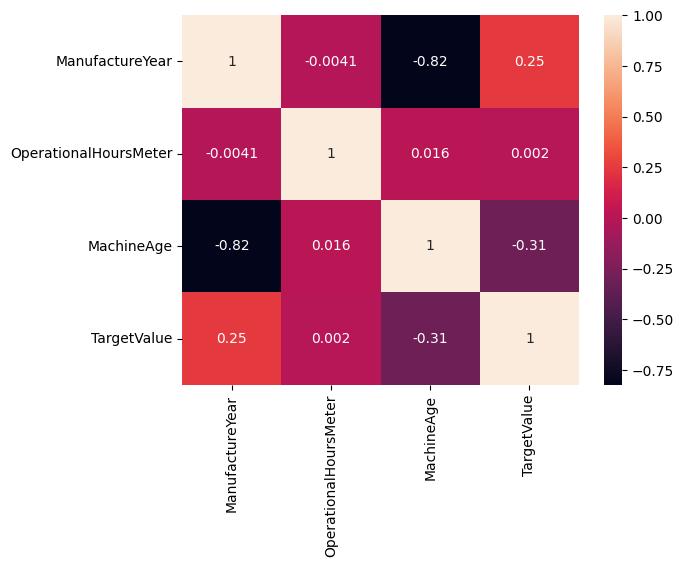

In [28]:
numeric_cols = ["ManufactureYear", "OperationalHoursMeter", "MachineAge", "TargetValue"]

sns.heatmap(train[numeric_cols].corr(), annot=True,)
plt.show()

### *TargetValue* has a <u>weak positive correlation</u> with *DataOriginCode*
### *TargetValue* has a <u>weak negative correlation</u> with *MachineAge*
### *MachineAge* has a <u>strong negative correlation</u> with *ManufactureYear*

# X - y split

In [29]:
X = train.drop(columns=['TargetValue'])
y = train['TargetValue']
X_test = test.copy()
X.shape, y.shape

((138701, 47), (138701,))

In [30]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.05, random_state=42
)

In [31]:
print(X_train.shape, y_train.shape, X_test.shape)

(131765, 47) (131765,) (15000, 47)


In [32]:
# List of categorical columns
cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Replacing float NANs with strings for categorical columns (if exists)
X_train[cat_features] = X_train[cat_features].fillna("missing")
X_test[cat_features] = X_test[cat_features].fillna("missing")
X_val[cat_features] = X_val[cat_features].fillna("missing")

# Pipeline

In [33]:
ordinal_cols = [
    'col1', 'CabinType', 'Forks', 'col3', 'col6', 'col8', 'col9', 
    'col11', 'col12', 'col13', 'col14', 'col16', 'col20', 
    'col23', 'col24', 'col29', 'col30'
]
robust_cols = ['col22']

# ColumnTransformer
col_transformer = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
        ('robust', RobustScaler(), robust_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False # The name of the columns do NOT change to avoid crashing later
)

# Pipeline
preprocessing_pipeline = Pipeline(steps=[
    ('columns', col_transformer)
])

preprocessing_pipeline.set_output(transform="pandas")

X_train = preprocessing_pipeline.fit_transform(X_train)
X_val = preprocessing_pipeline.transform(X_val)
X_test = preprocessing_pipeline.transform(X_test)
print("Done!")

Done!


In [34]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 48 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   float64
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101709 non-null  object 
 13  Spec_ReleaseSeries         32

# Check alignment of columns for train vs test before model training

In [35]:
c = 0
for (column1, column2) in zip(X_train, X_test):
    if column1 != column2:
        c+=1
        print((column1, column2))
print("Perfect!" if c==0 else "")

Perfect!


# Dummy Regressor

In [36]:
# from sklearn.dummy import DummyRegressor

# model = DummyRegressor()
# model.fit(X_train, y_train)

In [37]:
cat_features = list(set(ordinal_cols + X_train.select_dtypes(include=["object"]).columns.tolist()))

for col in cat_features:
    # Converting to simple strings to eliminate mixed data-type errors
    X_train[col] = X_train[col].astype(str)
    X_val[col] = X_val[col].astype(str)
    X_test[col] = X_test[col].astype(str)
    
    # Converting to the standard Pandas 'category' type so LightGBM and XGBoost works
    X_train[col] = X_train[col].astype("category")
    X_val[col] = X_val[col].astype("category")
    X_test[col] = X_test[col].astype("category")

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

# CatBoostRegressor

In [38]:
cb_model = CatBoostRegressor(
    iterations=50000,
    learning_rate=0.05, 
    depth=6,
    l2_leaf_reg=5,
    random_state=42,
    early_stopping_rounds=300,
)

cb_model.fit(
    X_train,
    y_train_log,
    eval_set=(X_val, y_val_log),
    cat_features=cat_features,
    verbose=5000,
)

cb_log_preds = cb_model.predict(X_val)
preds_cat = np.clip(np.expm1(cb_log_preds), 0, None)

print(f"RMSLE : {root_mean_squared_log_error(y_val, preds_cat):.4f}")
print(f"R2 Score: {r2_score(y_val, preds_cat):.4f}")

0:	learn: 0.6482517	test: 0.6420146	best: 0.6420146 (0)	total: 440ms	remaining: 6h 6m 48s
5000:	learn: 0.2023059	test: 0.2112748	best: 0.2112748 (5000)	total: 29m 38s	remaining: 4h 26m 46s
10000:	learn: 0.1879142	test: 0.2072351	best: 0.2072338 (9990)	total: 1h 1s	remaining: 4h 3s
15000:	learn: 0.1776934	test: 0.2054987	best: 0.2054975 (14999)	total: 1h 30m 44s	remaining: 3h 31m 43s
20000:	learn: 0.1693657	test: 0.2046408	best: 0.2046312 (19926)	total: 2h 1m 25s	remaining: 3h 2m 7s
25000:	learn: 0.1621701	test: 0.2039426	best: 0.2039357 (24980)	total: 2h 32m 9s	remaining: 2h 32m 9s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.2037709632
bestIteration = 26562

Shrink model to first 26563 iterations.
RMSLE : 0.2038
R2 Score: 0.9050


# LightGBMRegressor with HyperParameterTuning

In [39]:
from sklearn.model_selection import RandomizedSearchCV

base_lgb = lgb.LGBMRegressor(
    random_state=42,
    n_jobs=1,
    verbose=-1,
    subsample_freq=1,
)

param_distributions = {
    "num_leaves": [127, 255],
    "learning_rate": [0.05],
    "max_depth": [8, 10],
}

random_search = RandomizedSearchCV(
    estimator=lgb.LGBMRegressor(
        n_estimators=10000,
        random_state=42,
        n_jobs=1,
        verbose=-1
    ),
    param_distributions=param_distributions,
    n_iter=2,
    cv=2,
    n_jobs=-1)

random_search.fit(X_train, y_train_log)
print(random_search.best_params_)
lgb_model = random_search.best_estimator_

lgb_log_preds = lgb_model.predict(X_val)
preds_lgb = np.clip(np.expm1(lgb_log_preds), 0, None)

print(f"RMSLE : {root_mean_squared_log_error(y_val, preds_lgb):.4f}")
print(f"R2 Score: {r2_score(y_val, preds_lgb):.4f}")

{'num_leaves': 255, 'max_depth': 10, 'learning_rate': 0.05}
RMSLE : 0.2053
R2 Score: 0.9045


# XGBoostRegressor

In [40]:
xgb_model = XGBRegressor(
    n_estimators=30000,
    learning_rate=0.03,
    max_depth=6,
    tree_method="hist",
    enable_categorical=True, 
    random_state=42,
    early_stopping_rounds=200,
    eval_metric="rmse",
)

xgb_model.fit(
    X_train, 
    y_train_log, 
    eval_set=[(X_val, y_val_log)], 
    verbose=5000
)

xgb_log_preds = xgb_model.predict(X_val)
preds_xgb = np.clip(np.expm1(xgb_log_preds), 0, None)

print(f"RMSLE : {root_mean_squared_log_error(y_val, preds_xgb):.4f}")
print(f"R2 Score: {r2_score(y_val, preds_xgb):.4f}")

[0]	validation_0-rmse:0.65015
[3495]	validation_0-rmse:0.20793
RMSLE : 0.2079
R2 Score: 0.9026


# Comparison of models (RMSLE)

| Index/Models | CatBoost | LightGBM | XGBoost |
| :---: | :---: | :---: | :---: |
| 1 | 0.20 | 0.21 | 0.21 |
| 2 | 0.20 | 0.20 | 0.21 |
| 3 | 0.20 | 0.20 | 0.20 |
| Best | 0.21 | 0.20 | 0.20 |


# Comparison of models (R2)

| Index/Models | CatBoost | LightGBM | XGBoost |
| :---: | :---: | :---: | :---: |
| 1 | 0.91 | 0.90 | 0.90 |
| 2 | 0.91 | 0.91 | 0.90 |
| 3 | 0.90 | 0.90 | 0.90 |
| Best | 0.90 | 0.90 | 0.91 |


# Comparison of models (weights)

| Index/Models | CatBoost | LightGBM | XGBoost |
| :---: | :---: | :---: | :---: |
| 1 | 0.50 | 0.25 | 0.25 |
| 2 | 0.45 | 0.25 | 0.30 |
| 3 | 0.31 | 0.35 | 0.34 |
| Best | 0.42 | 0.31 | 0.27 |

# Ensembling

In [41]:
from scipy.optimize import minimize

ss = pd.DataFrame()
ss["TargetValue_CatBoost"] = np.clip(np.expm1(cb_model.predict(X_test)), 0, None)
ss["TargetValue_LightGBM"] = np.clip(np.expm1(lgb_model.predict(X_test)), 0, None)
ss["TargetValue_XGBoost"] = np.clip(np.expm1(xgb_model.predict(X_test)), 0, None)

val_preds = np.array([preds_cat, preds_lgb, preds_xgb])

def loss_func(w):
    predictions = np.dot(w, val_preds)
    predictions = np.clip(predictions, 0, None)
    return root_mean_squared_log_error(y_val, predictions)

cons = {
    'type': 'eq',
    'fun' : lambda w: np.array([1.0 - np.sum(w)]),
    'jac' : lambda w: np.array([-1.0, -1.0, -1.0])
}

starting_weights = np.array([0.5, 0.25, 0.25])
bounds = [(0, 1)] * 3

# SLSQP -> Sequential Least Square Programming
# ftol -> function tolerance
# disp -> display
res = minimize(loss_func, starting_weights, method='SLSQP', options={'ftol': 1e-9, 'disp': True}, bounds=bounds, constraints=[cons])

print(f"Best RMSLE: {res.fun:.5f}")
print(f"Optimal Weights: Cat={res.x[0]:.4f}, LGB={res.x[1]:.4f}, XGB={res.x[2]:.4f}")

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.1937442084520438
            Iterations: 11
            Function evaluations: 44
            Gradient evaluations: 11
Best RMSLE: 0.19374
Optimal Weights: Cat=0.4352, LGB=0.3408, XGB=0.2241


# Final Steps

In [42]:
w_cat_best, w_lgb_best, w_xgb_best = res.x

sample_["TargetValue"] = (
    (w_cat_best * ss["TargetValue_CatBoost"]) +
    (w_lgb_best * ss["TargetValue_LightGBM"]) +
    (w_xgb_best * ss["TargetValue_XGBoost"])
)

final_submission = pd.DataFrame({
    "TransactionID": sample_["TransactionID"],
    "TargetValue": sample_["TargetValue"]
})

final_submission.to_csv("submission.csv", index=False)
print("New submission.csv created!")

New submission.csv created!
